In [5]:
import numpy as np

def croston_classic(ts, alpha=0.1, n_forecast=7):
    ts = np.array(ts)
    n = len(ts)
    demand = np.where(ts != 0, ts, np.nan)
    interval = np.full_like(ts, np.nan, dtype='float')
    
    # Talep gelen noktalar arası aralık
    last_demand_index = np.nan
    for i in range(n):
        if ts[i] != 0:
            if np.isnan(last_demand_index):
                interval[i] = np.nan
            else:
                interval[i] = i - last_demand_index
            last_demand_index = i

    a_demand = np.nanmean(demand)
    a_interval = np.nanmean(interval)

    forecasts = []
    for _ in range(n_forecast):
        forecasts.append(a_demand / a_interval if a_interval > 0 else 0)

    return forecasts


In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# 1. Veriyi oku ve hazırla
df = pd.read_excel('../preprocessedBelgeler/maped_zero_filled_forecastData_altLimit100_son3_byGrup.xlsx')
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# Aylık Grade bazlı toplam talep
monthly_grade = df.groupby(['Month', 'Grade'])['Sipariş Mik. (TON)'].sum().reset_index()
grade_list = monthly_grade['Grade'].unique()

forecast_df = pd.DataFrame()
disaggregated_df = pd.DataFrame()
mae_list = []
mape_list = []

for grade in grade_list:
    # 2. Grade bazlı zaman serisini oluştur
    grade_data = monthly_grade[monthly_grade['Grade'] == grade].set_index('Month')
    grade_data = grade_data.loc['2022-01':'2024-05']  # Eğitim verisi
    y_train = grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0).values

    # Eğer sabit ya da boş seri ise atla
    if np.std(y_train) < 1e-3 or np.sum(y_train) == 0:
        print(f"'{grade}' atlandı çünkü zaman serisi sabit veya boş.")
        continue

    # 3. Croston tahmini
    forecast_vals = croston_classic(y_train, alpha=0.1, n_forecast=7)

    forecast_index = pd.date_range(start='2024-06-01', periods=7, freq='MS')
    
    # 4. Tahmini df'e yaz
    temp_forecast = pd.DataFrame({
        'Month': forecast_index,
        'Grade': grade,
        'Forecast_TON': forecast_vals[-7:]
    })
    forecast_df = pd.concat([forecast_df, temp_forecast], ignore_index=True)

    # 5. Disaggregation (SpecGroupId'lere dağıtım)
    for month, forecast_ton in zip(forecast_index, forecast_vals[-7:]):
        # Aynı ayın geçmiş yıllarındaki dağılım oranlarını kullan
        past_months = df[(df['Grade'] == grade) & (df['Month'].dt.month == month.month)]
        past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
        total = past_months_total.sum()

        if total == 0:  # fallback
            past_months = df[df['Grade'] == grade]
            past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
            total = past_months_total.sum()

        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında geçmiş veri bulunamadı.")
            continue

        proportions = past_months_total / total
        disagg = proportions * forecast_ton

        for spec_id, miktar in disagg.items():
            disaggregated_df = pd.concat([disaggregated_df, pd.DataFrame({
                'Month': [month],
                'Grade': [grade],
                'SpecGroupId': [spec_id],
                'Forecast_TON': [miktar]
            })])

        # 6. Gerçeklerle kıyas
        actual_df = df[(df['Month'] == month) & (df['Grade'] == grade)]
        actual_agg = actual_df.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()

        forecast_agg = disaggregated_df[
            (disaggregated_df['Month'] == month) &
            (disaggregated_df['Grade'] == grade)
        ].groupby('SpecGroupId')['Forecast_TON'].sum()

        common_index = actual_agg.index.intersection(forecast_agg.index)

        if len(common_index) > 0:
            actual_vals = actual_agg.loc[common_index]
            pred_vals = forecast_agg.loc[common_index]

            for spec_id in common_index:
                disagg_metrics = {
                    'Grade': grade,
                    'Month': month,
                    'SpecGroupId': spec_id,
                    'MAE_Disagg': abs(actual_vals[spec_id] - pred_vals[spec_id]),
                    'MAPE_Disagg': abs((actual_vals[spec_id] - pred_vals[spec_id]) / actual_vals[spec_id]) if actual_vals[spec_id] != 0 else np.nan
                }
                mae_list.append(disagg_metrics)

# → forecast_df = grade bazlı tahminler
# → disaggregated_df = specGroupId bazlı dağılmış tahminler
# → mae_list = hata metrikleri



'0.0' atlandı çünkü zaman serisi sabit veya boş.
'6.65' atlandı çünkü zaman serisi sabit veya boş.
'10.0' atlandı çünkü zaman serisi sabit veya boş.
'10.15' atlandı çünkü zaman serisi sabit veya boş.
'19.02' atlandı çünkü zaman serisi sabit veya boş.
'25.0' atlandı çünkü zaman serisi sabit veya boş.
'27.0' atlandı çünkü zaman serisi sabit veya boş.
'33.15' atlandı çünkü zaman serisi sabit veya boş.
'33.39' atlandı çünkü zaman serisi sabit veya boş.
'33.74' atlandı çünkü zaman serisi sabit veya boş.
'36.825' atlandı çünkü zaman serisi sabit veya boş.
'40.0' atlandı çünkü zaman serisi sabit veya boş.
'41.0' atlandı çünkü zaman serisi sabit veya boş.
'42.13' atlandı çünkü zaman serisi sabit veya boş.
'43.14' atlandı çünkü zaman serisi sabit veya boş.
'44.89' atlandı çünkü zaman serisi sabit veya boş.
'45.685' atlandı çünkü zaman serisi sabit veya boş.
'46.33' atlandı çünkü zaman serisi sabit veya boş.
'51.0' atlandı çünkü zaman serisi sabit veya boş.
'52.09' atlandı çünkü zaman serisi sab

/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anac

'228.0' atlandı çünkü zaman serisi sabit veya boş.
'229.865' atlandı çünkü zaman serisi sabit veya boş.
'261.115' atlandı çünkü zaman serisi sabit veya boş.
'270.32' atlandı çünkü zaman serisi sabit veya boş.
'276.47' atlandı çünkü zaman serisi sabit veya boş.
'285.0' atlandı çünkü zaman serisi sabit veya boş.
'295.0' atlandı çünkü zaman serisi sabit veya boş.
'319.23' atlandı çünkü zaman serisi sabit veya boş.
'320.56' atlandı çünkü zaman serisi sabit veya boş.
'321.36' atlandı çünkü zaman serisi sabit veya boş.
'381.015' atlandı çünkü zaman serisi sabit veya boş.
'390.22' atlandı çünkü zaman serisi sabit veya boş.
'410.315' atlandı çünkü zaman serisi sabit veya boş.
'429.0' atlandı çünkü zaman serisi sabit veya boş.
'431.0' atlandı çünkü zaman serisi sabit veya boş.
'440.002' atlandı çünkü zaman serisi sabit veya boş.
'441.88' atlandı çünkü zaman serisi sabit veya boş.
'466.235' atlandı çünkü zaman serisi sabit veya boş.
'468.83' atlandı çünkü zaman serisi sabit veya boş.
'478.93' at

/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anac

'564.32' atlandı çünkü zaman serisi sabit veya boş.
'590.0' atlandı çünkü zaman serisi sabit veya boş.
'615.25' atlandı çünkü zaman serisi sabit veya boş.
'617.0' atlandı çünkü zaman serisi sabit veya boş.
'659.4' atlandı çünkü zaman serisi sabit veya boş.
'682.121' atlandı çünkü zaman serisi sabit veya boş.
'700.0' atlandı çünkü zaman serisi sabit veya boş.
'772.48' atlandı çünkü zaman serisi sabit veya boş.
'803.49' atlandı çünkü zaman serisi sabit veya boş.
'904.665' atlandı çünkü zaman serisi sabit veya boş.
'960.256' atlandı çünkü zaman serisi sabit veya boş.
'970.0' atlandı çünkü zaman serisi sabit veya boş.
'989.5699999999999' atlandı çünkü zaman serisi sabit veya boş.
'1064.041' atlandı çünkü zaman serisi sabit veya boş.
'1079.23' atlandı çünkü zaman serisi sabit veya boş.
'1091.107' atlandı çünkü zaman serisi sabit veya boş.
'1104.52' atlandı çünkü zaman serisi sabit veya boş.
'1377.24' atlandı çünkü zaman serisi sabit veya boş.
'1746.81' atlandı çünkü zaman serisi sabit veya 

...

/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anac

'2202.53' atlandı çünkü zaman serisi sabit veya boş.
'9251.72' atlandı çünkü zaman serisi sabit veya boş.
'6.74' atlandı çünkü zaman serisi sabit veya boş.
'7.53' atlandı çünkü zaman serisi sabit veya boş.
'10.03' atlandı çünkü zaman serisi sabit veya boş.
'16.01' atlandı çünkü zaman serisi sabit veya boş.
'19.5' atlandı çünkü zaman serisi sabit veya boş.
'21.45' atlandı çünkü zaman serisi sabit veya boş.
'26.09' atlandı çünkü zaman serisi sabit veya boş.
'42.52' atlandı çünkü zaman serisi sabit veya boş.
'68.02' atlandı çünkü zaman serisi sabit veya boş.
'109.62' atlandı çünkü zaman serisi sabit veya boş.
'112.94' atlandı çünkü zaman serisi sabit veya boş.
'121.28' atlandı çünkü zaman serisi sabit veya boş.
'135.16' atlandı çünkü zaman serisi sabit veya boş.
'136.649' atlandı çünkü zaman serisi sabit veya boş.
'147.619' atlandı çünkü zaman serisi sabit veya boş.
'154.58' atlandı çünkü zaman serisi sabit veya boş.
'185.6' atlandı çünkü zaman serisi sabit veya boş.
'268.67' atlandı çünk

/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anac

'138.77' atlandı çünkü zaman serisi sabit veya boş.
'140.79' atlandı çünkü zaman serisi sabit veya boş.
'152.5' atlandı çünkü zaman serisi sabit veya boş.
'171.5' atlandı çünkü zaman serisi sabit veya boş.
'175.86' atlandı çünkü zaman serisi sabit veya boş.
'180.39' atlandı çünkü zaman serisi sabit veya boş.
'191.32' atlandı çünkü zaman serisi sabit veya boş.
'210.67' atlandı çünkü zaman serisi sabit veya boş.
'242.65' atlandı çünkü zaman serisi sabit veya boş.
'265.456' atlandı çünkü zaman serisi sabit veya boş.
'271.22' atlandı çünkü zaman serisi sabit veya boş.
'278.9' atlandı çünkü zaman serisi sabit veya boş.
'303.43' atlandı çünkü zaman serisi sabit veya boş.
'307.9' atlandı çünkü zaman serisi sabit veya boş.
'313.146' atlandı çünkü zaman serisi sabit veya boş.
'323.41' atlandı çünkü zaman serisi sabit veya boş.
'330.23' atlandı çünkü zaman serisi sabit veya boş.
'366.24' atlandı çünkü zaman serisi sabit veya boş.
'369.8' atlandı çünkü zaman serisi sabit veya boş.
'374.5' atlandı

/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anac

In [3]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np
import pandas as pd

# 🎯 Grade bazlı performans metriklerini hesapla
grade_metrics = []

# forecast_df: grade bazlı Croston tahminleri (Month, Grade, Forecast_TON)
# monthly_grade: gerçek değerler (Month, Grade, Sipariş Mik. (TON))

for grade in forecast_df['Grade'].unique():
    # Tahmin edilen veriler
    pred_series = forecast_df[forecast_df['Grade'] == grade].set_index('Month')['Forecast_TON']
    
    # Gerçek veriler
    actual_series = monthly_grade[monthly_grade['Grade'] == grade].set_index('Month')['Sipariş Mik. (TON)']
    
    # Ortak aylar
    common_months = pred_series.index.intersection(actual_series.index)
    
    if len(common_months) == 0:
        continue

    y_true = actual_series.loc[common_months]
    y_pred = pred_series.loc[common_months]

    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

    grade_metrics.append({
        'Grade': grade,
        'MAE': mae,
        'MAPE (%)': mape,
        'sMAPE (%)': smape,
        'wMAPE (%)': wmape,
        'RMSE': rmse
    })

# 🎉 Sonuçları tablo olarak göster
grade_metrics_df = pd.DataFrame(grade_metrics)
print("\n📊 Croston – Grade Bazlı Tahmin Performansı:")
print(grade_metrics_df)

# Kaydetmek istersen:
# grade_metrics_df.to_excel("croston_grade_metrics_summary.xlsx", index=False)


'0.0' atlandı çünkü zaman serisi sabit veya boş.
'6.65' atlandı çünkü zaman serisi sabit veya boş.
'10.0' atlandı çünkü zaman serisi sabit veya boş.
'10.15' atlandı çünkü zaman serisi sabit veya boş.
'19.02' atlandı çünkü zaman serisi sabit veya boş.
'25.0' atlandı çünkü zaman serisi sabit veya boş.
'27.0' atlandı çünkü zaman serisi sabit veya boş.
'33.15' atlandı çünkü zaman serisi sabit veya boş.
'33.39' atlandı çünkü zaman serisi sabit veya boş.
'33.74' atlandı çünkü zaman serisi sabit veya boş.
'36.825' atlandı çünkü zaman serisi sabit veya boş.
'40.0' atlandı çünkü zaman serisi sabit veya boş.
'41.0' atlandı çünkü zaman serisi sabit veya boş.
'42.13' atlandı çünkü zaman serisi sabit veya boş.
'43.14' atlandı çünkü zaman serisi sabit veya boş.
'44.89' atlandı çünkü zaman serisi sabit veya boş.
'45.685' atlandı çünkü zaman serisi sabit veya boş.
'46.33' atlandı çünkü zaman serisi sabit veya boş.
'51.0' atlandı çünkü zaman serisi sabit veya boş.
'52.09' atlandı çünkü zaman serisi sab

/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anac

'155.0' atlandı çünkü zaman serisi sabit veya boş.
'161.0' atlandı çünkü zaman serisi sabit veya boş.
'165.56' atlandı çünkü zaman serisi sabit veya boş.
'186.0' atlandı çünkü zaman serisi sabit veya boş.
'198.565' atlandı çünkü zaman serisi sabit veya boş.
'198.61' atlandı çünkü zaman serisi sabit veya boş.
'200.31' atlandı çünkü zaman serisi sabit veya boş.
'209.66' atlandı çünkü zaman serisi sabit veya boş.
'223.0' atlandı çünkü zaman serisi sabit veya boş.
'225.0' atlandı çünkü zaman serisi sabit veya boş.
'228.0' atlandı çünkü zaman serisi sabit veya boş.
'229.865' atlandı çünkü zaman serisi sabit veya boş.
'261.115' atlandı çünkü zaman serisi sabit veya boş.
'270.32' atlandı çünkü zaman serisi sabit veya boş.
'276.47' atlandı çünkü zaman serisi sabit veya boş.
'285.0' atlandı çünkü zaman serisi sabit veya boş.
'295.0' atlandı çünkü zaman serisi sabit veya boş.
'319.23' atlandı çünkü zaman serisi sabit veya boş.
'320.56' atlandı çünkü zaman serisi sabit veya boş.
'321.36' atlandı 

/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anac

'94.41' atlandı çünkü zaman serisi sabit veya boş.
'94.5' atlandı çünkü zaman serisi sabit veya boş.
'104.0' atlandı çünkü zaman serisi sabit veya boş.
'105.0' atlandı çünkü zaman serisi sabit veya boş.
'121.0' atlandı çünkü zaman serisi sabit veya boş.
'121.706' atlandı çünkü zaman serisi sabit veya boş.
'129.84' atlandı çünkü zaman serisi sabit veya boş.
'130.0' atlandı çünkü zaman serisi sabit veya boş.
'155.39' atlandı çünkü zaman serisi sabit veya boş.
'156.7' atlandı çünkü zaman serisi sabit veya boş.
'158.0' atlandı çünkü zaman serisi sabit veya boş.
'171.0' atlandı çünkü zaman serisi sabit veya boş.
'182.505' atlandı çünkü zaman serisi sabit veya boş.
'186.04' atlandı çünkü zaman serisi sabit veya boş.
'208.0' atlandı çünkü zaman serisi sabit veya boş.
'224.0' atlandı çünkü zaman serisi sabit veya boş.
'248.661' atlandı çünkü zaman serisi sabit veya boş.
'294.13' atlandı çünkü zaman serisi sabit veya boş.
'310.61' atlandı çünkü zaman serisi sabit veya boş.
'318.94' atlandı çünk

...

'107.11' atlandı çünkü zaman serisi sabit veya boş.
'109.25' atlandı çünkü zaman serisi sabit veya boş.
'116.32' atlandı çünkü zaman serisi sabit veya boş.
'125.19' atlandı çünkü zaman serisi sabit veya boş.
'156.33' atlandı çünkü zaman serisi sabit veya boş.
'161.3' atlandı çünkü zaman serisi sabit veya boş.
'163.6' atlandı çünkü zaman serisi sabit veya boş.
'171.51' atlandı çünkü zaman serisi sabit veya boş.
'171.75' atlandı çünkü zaman serisi sabit veya boş.
'182.5' atlandı çünkü zaman serisi sabit veya boş.
'189.71' atlandı çünkü zaman serisi sabit veya boş.
'220.95' atlandı çünkü zaman serisi sabit veya boş.
'226.81' atlandı çünkü zaman serisi sabit veya boş.
'230.64' atlandı çünkü zaman serisi sabit veya boş.
'240.25' atlandı çünkü zaman serisi sabit veya boş.
'255.01' atlandı çünkü zaman serisi sabit veya boş.
'255.2' atlandı çünkü zaman serisi sabit veya boş.
'268.082' atlandı çünkü zaman serisi sabit veya boş.
'279.51' atlandı çünkü zaman serisi sabit veya boş.
'282.15' atland

/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anac

'600.8' atlandı çünkü zaman serisi sabit veya boş.
'627.0' atlandı çünkü zaman serisi sabit veya boş.
'634.201' atlandı çünkü zaman serisi sabit veya boş.
'656.905' atlandı çünkü zaman serisi sabit veya boş.
'671.546' atlandı çünkü zaman serisi sabit veya boş.
'677.575' atlandı çünkü zaman serisi sabit veya boş.
'687.1' atlandı çünkü zaman serisi sabit veya boş.
'706.26' atlandı çünkü zaman serisi sabit veya boş.
'829.44' atlandı çünkü zaman serisi sabit veya boş.
'919.24' atlandı çünkü zaman serisi sabit veya boş.
'982.842' atlandı çünkü zaman serisi sabit veya boş.
'1012.15' atlandı çünkü zaman serisi sabit veya boş.
'1030.63' atlandı çünkü zaman serisi sabit veya boş.
'1054.0' atlandı çünkü zaman serisi sabit veya boş.
'1059.62' atlandı çünkü zaman serisi sabit veya boş.
'1075.22' atlandı çünkü zaman serisi sabit veya boş.
'1158.89' atlandı çünkü zaman serisi sabit veya boş.
'1193.425' atlandı çünkü zaman serisi sabit veya boş.
'1298.18' atlandı çünkü zaman serisi sabit veya boş.
'1

'19.38' atlandı çünkü zaman serisi sabit veya boş.
'21.88' atlandı çünkü zaman serisi sabit veya boş.
'22.35' atlandı çünkü zaman serisi sabit veya boş.
'22.63' atlandı çünkü zaman serisi sabit veya boş.
'23.06' atlandı çünkü zaman serisi sabit veya boş.
'23.18' atlandı çünkü zaman serisi sabit veya boş.
'28.65' atlandı çünkü zaman serisi sabit veya boş.
'37.9' atlandı çünkü zaman serisi sabit veya boş.
'45.96' atlandı çünkü zaman serisi sabit veya boş.
'50.19' atlandı çünkü zaman serisi sabit veya boş.
'51.35' atlandı çünkü zaman serisi sabit veya boş.
'54.67' atlandı çünkü zaman serisi sabit veya boş.
'56.2' atlandı çünkü zaman serisi sabit veya boş.
'74.65' atlandı çünkü zaman serisi sabit veya boş.
'82.92' atlandı çünkü zaman serisi sabit veya boş.
'91.03999999999999' atlandı çünkü zaman serisi sabit veya boş.
'116.97' atlandı çünkü zaman serisi sabit veya boş.
'127.23' atlandı çünkü zaman serisi sabit veya boş.
'137.351' atlandı çünkü zaman serisi sabit veya boş.
'138.77' atlandı 

/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/cankocak/anac

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd

# 🎯 1. Gerçek veriyi filtrele
actual_all = monthly_grade[
    (monthly_grade['Month'] >= '2024-06') & 
    (monthly_grade['Month'] <= '2024-12')
]

# 🎯 2. Tahmin ile birleştir
merged_all = pd.merge(
    actual_all, 
    forecast_df, 
    on=['Month', 'Grade'], 
    how='inner'
)

# 🎯 3. NaN'leri at
merged_all.dropna(subset=['Sipariş Mik. (TON)', 'Forecast_TON'], inplace=True)

# 🎯 4. Hedef serileri
y_true_all = merged_all['Sipariş Mik. (TON)']
y_pred_all = merged_all['Forecast_TON']

# 🎯 5. Hata metrikleri
mae_all = mean_absolute_error(y_true_all, y_pred_all)
mape_all = mean_absolute_percentage_error(y_true_all, y_pred_all) * 100
rmse_all = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
smape_all = 100 * np.mean(2 * np.abs(y_pred_all - y_true_all) / (np.abs(y_true_all) + np.abs(y_pred_all)))
wmape_all = 100 * np.sum(np.abs(y_pred_all - y_true_all)) / np.sum(np.abs(y_true_all))

# 📢 6. Yazdır
print("\n📦 Tüm Grade'ler için TOPLAM tahmin performansı:")
print(f"MAE   : {mae_all:.2f}")
print(f"MAPE  : {mape_all:.2f}%")
print(f"sMAPE : {smape_all:.2f}%")
print(f"wMAPE : {wmape_all:.2f}%")
print(f"RMSE  : {rmse_all:.2f}")



📦 Tüm Grade'ler için TOPLAM tahmin performansı:
MAE   : 2719.35
MAPE  : 585032273578579066880.00%
sMAPE : 158.21%
wMAPE : 103.71%
RMSE  : 5477.50


⏳ 2024-06 ayı için CROSTON grafiği hazırlanıyor...


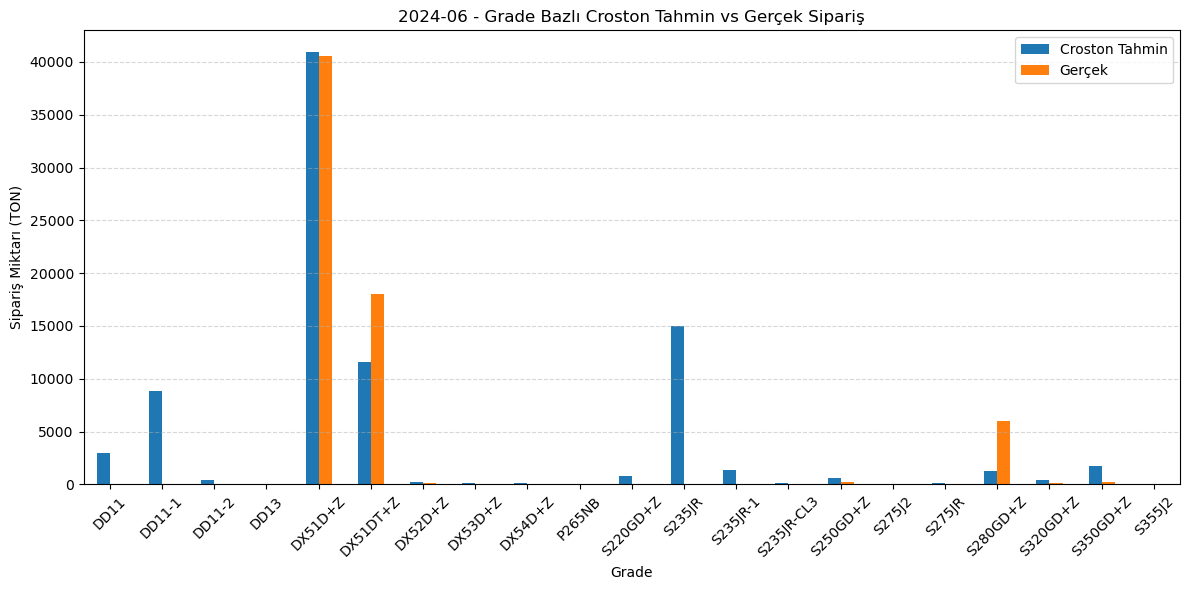

⏳ 2024-07 ayı için CROSTON grafiği hazırlanıyor...


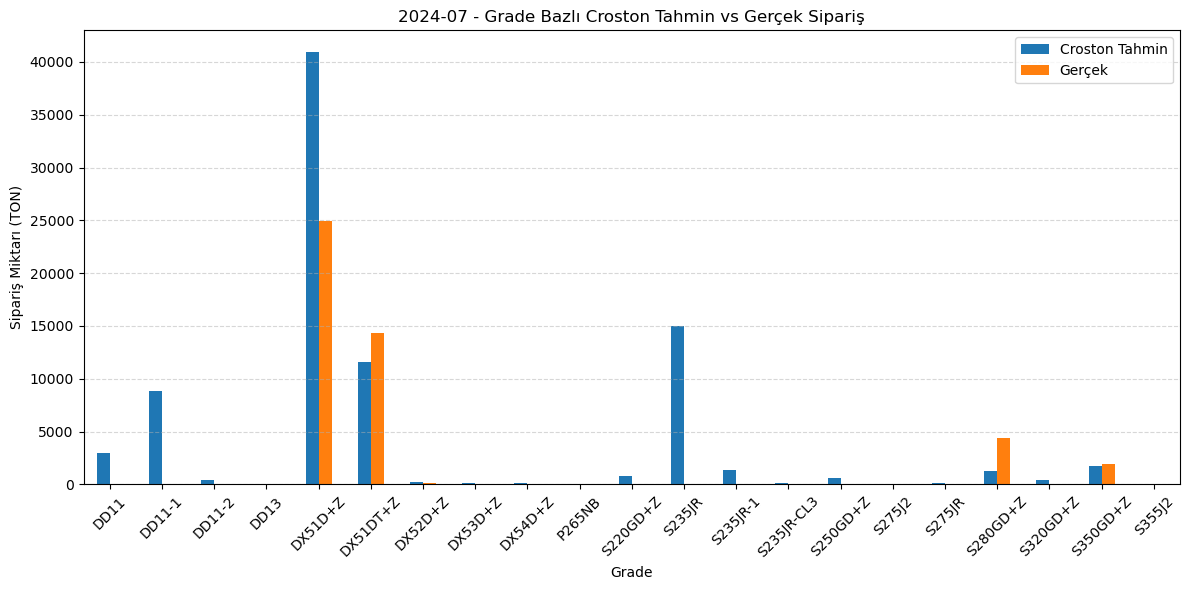

⏳ 2024-08 ayı için CROSTON grafiği hazırlanıyor...


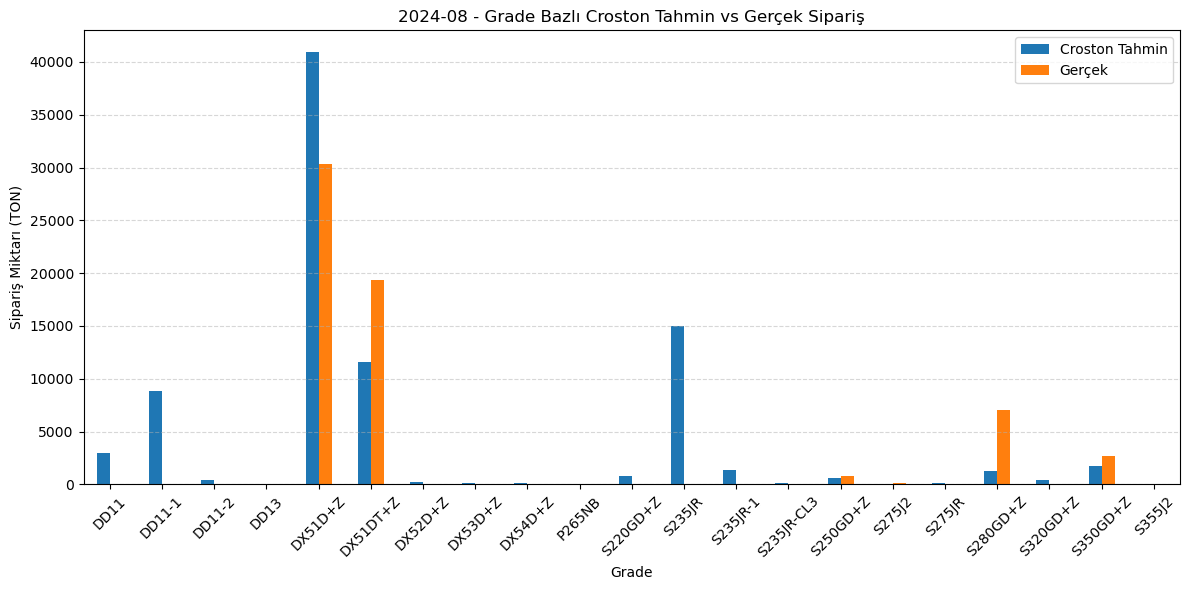

⏳ 2024-09 ayı için CROSTON grafiği hazırlanıyor...


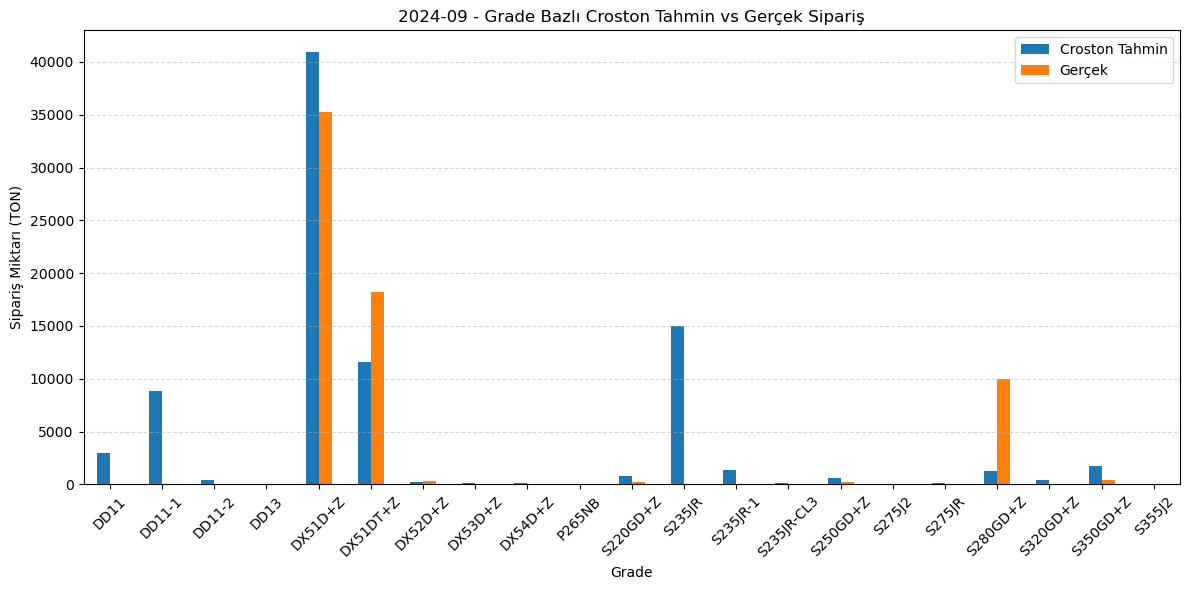

⏳ 2024-10 ayı için CROSTON grafiği hazırlanıyor...


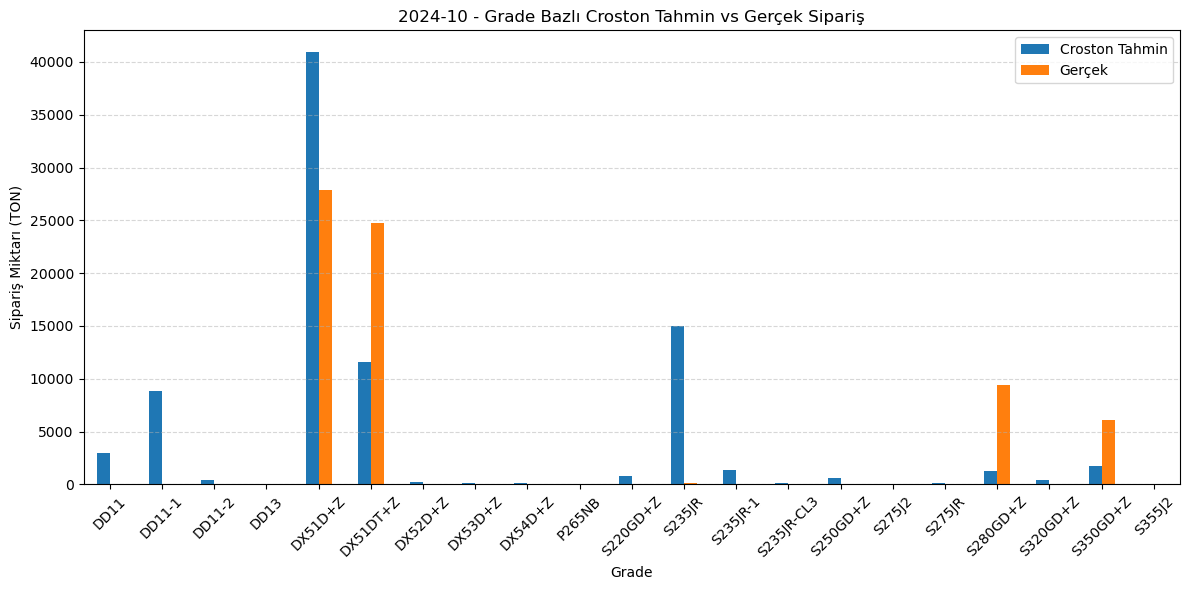

⏳ 2024-11 ayı için CROSTON grafiği hazırlanıyor...


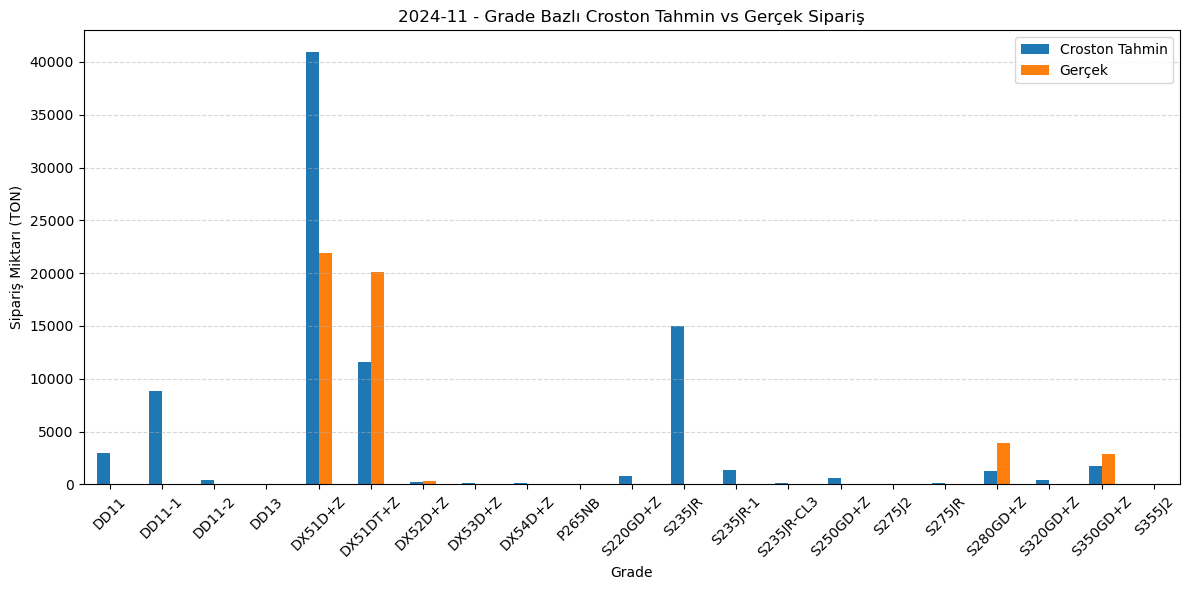

⏳ 2024-12 ayı için CROSTON grafiği hazırlanıyor...


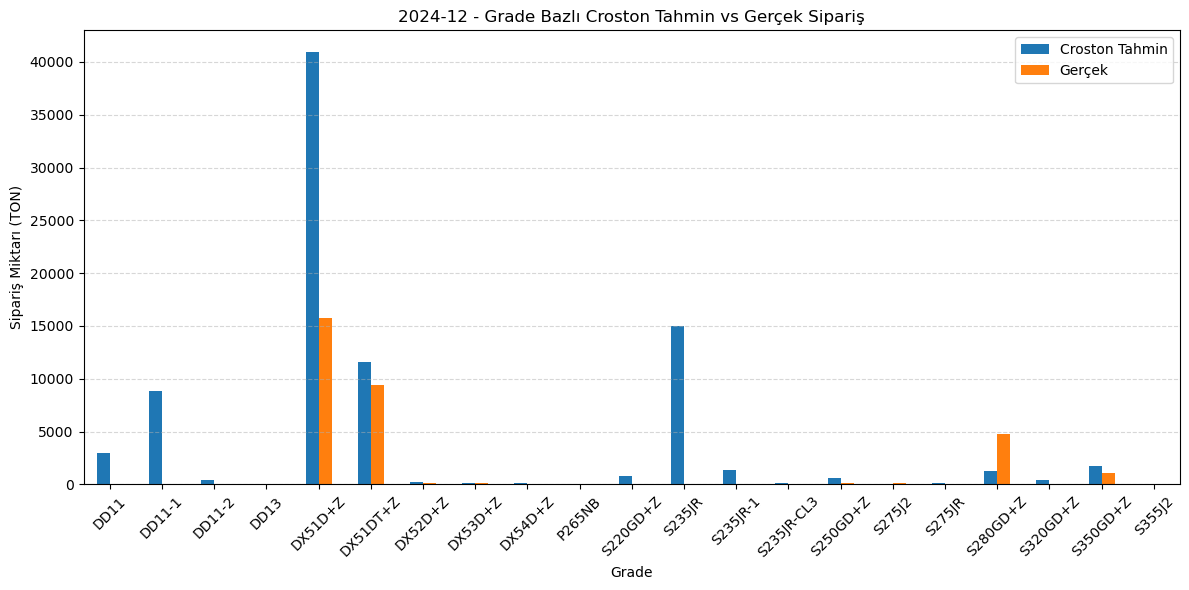

In [11]:
import matplotlib.pyplot as plt

# 🎯 Hedef aylar
target_months = ['2024-06','2024-07','2024-08', '2024-09', '2024-10','2024-11','2024-12']

for month in target_months:
    print(f"⏳ {month} ayı için CROSTON grafiği hazırlanıyor...")

    forecast_m = forecast_df[forecast_df['Month'] == month]  # ← Croston forecast
    actual_m = monthly_grade[monthly_grade['Month'] == month]  # Gerçek değerler

    # Verileri aynı forma sok
    forecast_m = forecast_m[['Grade', 'Forecast_TON']].set_index('Grade')
    actual_m = actual_m[['Grade', 'Sipariş Mik. (TON)']].set_index('Grade')

    # Ortak grade'leri al
    common_grades = forecast_m.index.intersection(actual_m.index)

    if len(common_grades) == 0:
        print(f"⚠️ {month} için hem tahmin hem gerçek veri yok.")
        continue

    compare_df = pd.DataFrame({
        'Forecast (Croston)': forecast_m.loc[common_grades]['Forecast_TON'],
        'Actual': actual_m.loc[common_grades]['Sipariş Mik. (TON)']
    }).sort_index()

    # Bar chart
    compare_df.plot(kind='bar', figsize=(12,6), color=['#1f77b4', '#ff7f0e'])
    plt.title(f"{month} - Grade Bazlı Croston Tahmin vs Gerçek Sipariş")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.xlabel("Grade")
    plt.xticks(rotation=45)
    plt.legend(["Croston Tahmin", "Gerçek"])
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()


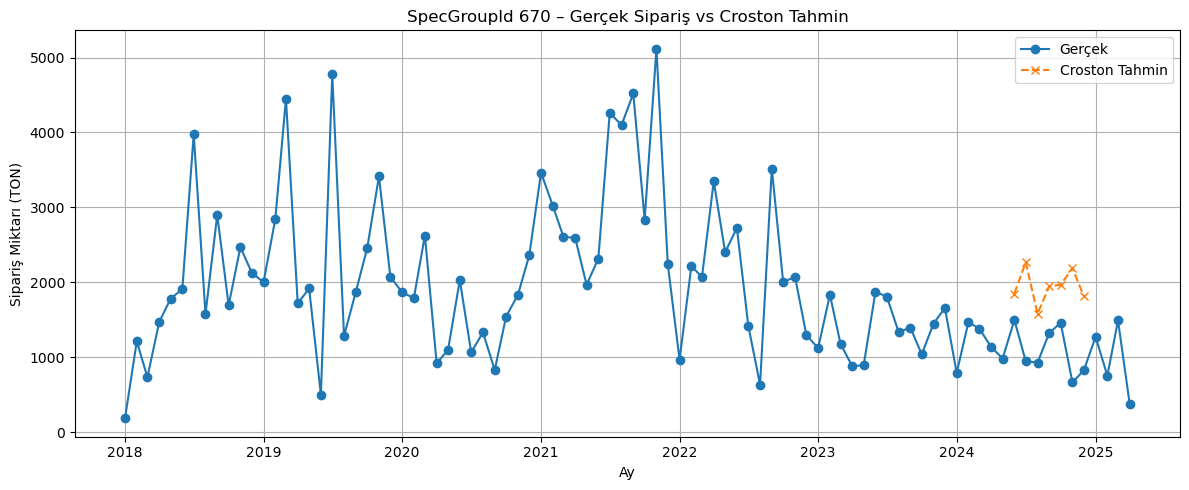

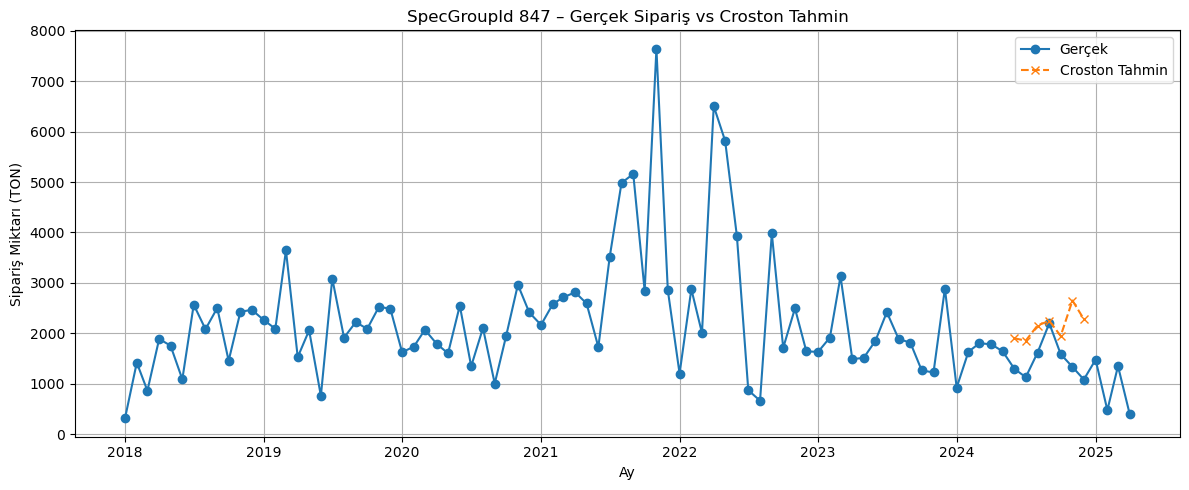

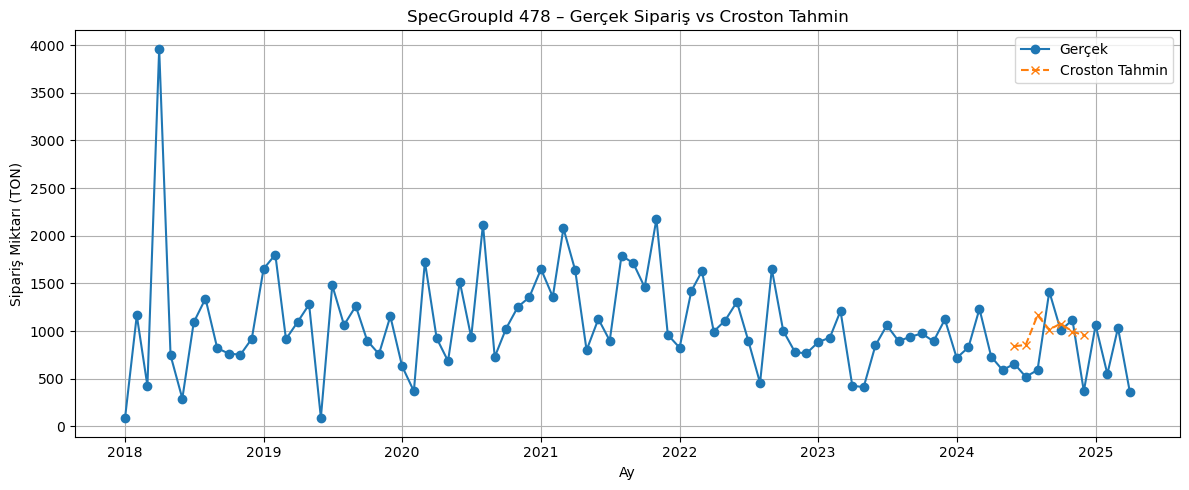

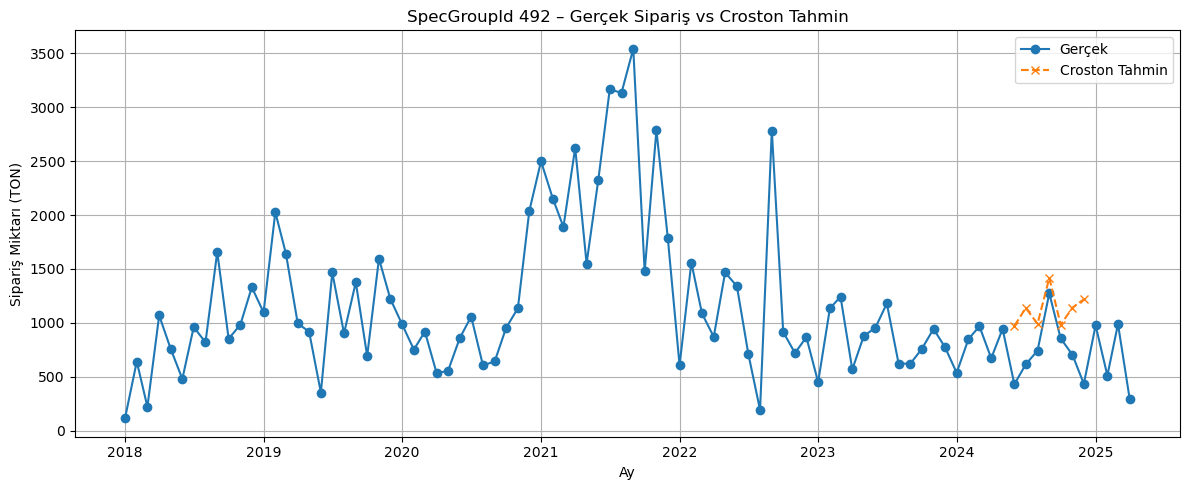

In [12]:
import matplotlib.pyplot as plt

# 🎯 Croston tahmini yapılan SpecGroupId'leri görselleştir
selected_spec_ids = ['670', '847', '478', '492']

for spec_id in selected_spec_ids:
    actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
    actual_series = actual_series.groupby('Month').sum().sort_index()
    actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

    forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
    forecast_series = forecast_series.groupby('Month').sum().sort_index()
    forecast_series.rename(columns={'Forecast_TON': 'Croston Forecast'}, inplace=True)

    merged = pd.concat([actual_series, forecast_series], axis=1)

    plt.figure(figsize=(12, 5))
    plt.plot(merged.index, merged['Actual'], label='Gerçek', marker='o')
    plt.plot(merged.index, merged['Croston Forecast'], label='Croston Tahmin', linestyle='--', marker='x')
    plt.title(f"SpecGroupId {spec_id} – Gerçek Sipariş vs Croston Tahmin")
    plt.xlabel("Ay")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [13]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

selected_spec_ids = ['670', '847', '478', '492']
metrics_df = pd.DataFrame(columns=['SpecGroupId', 'MAE', 'MAPE (%)', 'sMAPE (%)', 'wMAPE (%)', 'RMSE'])

for spec_id in selected_spec_ids:
    actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
    actual_series = actual_series.groupby('Month').sum().sort_index()
    actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

    forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
    forecast_series = forecast_series.groupby('Month').sum().sort_index()
    forecast_series.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

    merged = pd.concat([actual_series, forecast_series], axis=1).dropna()

    if len(merged) == 0:
        continue

    mae = mean_absolute_error(merged['Actual'], merged['Forecast'])
    mape = mean_absolute_percentage_error(merged['Actual'], merged['Forecast']) * 100
    rmse = np.sqrt(mean_squared_error(merged['Actual'], merged['Forecast']))
    smape = 100 * np.mean(2 * np.abs(merged['Forecast'] - merged['Actual']) /
                          (np.abs(merged['Actual']) + np.abs(merged['Forecast'])))
    wmape = 100 * np.sum(np.abs(merged['Forecast'] - merged['Actual'])) / np.sum(np.abs(merged['Actual']))

    metrics_df = metrics_df.append({
        'SpecGroupId': spec_id,
        'MAE': mae,
        'MAPE (%)': mape,
        'sMAPE (%)': smape,
        'wMAPE (%)': wmape,
        'RMSE': rmse
    }, ignore_index=True)

# 📊 Sonuçları göster
print("📈 Croston – SpecGroupId Bazlı Performans:")
print(metrics_df)


📈 Croston – SpecGroupId Bazlı Performans:
  SpecGroupId         MAE   MAPE (%)  sMAPE (%)  wMAPE (%)        RMSE
0         670  853.167496  95.034153  57.858371  78.145555  944.640687
1         847  684.444623  53.964154  39.221531  46.710432  799.964925
2         478  325.272431  56.517025  39.831754  40.096733  378.775917
3         492  400.768753  73.495272  47.551963  55.564868  458.576918


/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_37626/1449213895.py:29: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_37626/1449213895.py:29: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_37626/1449213895.py:29: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_37626/1449213895.py:29: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.appen

In [27]:
#OVERFIT TEST
import pandas as pd
import numpy as np

# Excel dosyasını oku
df = pd.read_excel("../preprocessedBelgeler/maped_zero_filled_forecastData_altLimit100_son3_byGrup.xlsx")  # kendi dosya yolunu yaz

# Gerekli kolonları adlandır ve temizle
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# Grade bazında aylık talep hesapla
monthly_grade = df.groupby(['Month', 'Grade'])['Sipariş Mik. (TON)'].sum().reset_index()


In [29]:
train_forecast_df = pd.DataFrame()
grade_list = monthly_grade['Grade'].unique()

for grade in grade_list:
    # Eğitim aralığını filtrele
    grade_data = monthly_grade[
        (monthly_grade['Grade'] == grade) &
        (monthly_grade['Month'] >= '2022-01') &
        (monthly_grade['Month'] <= '2024-05')
    ].copy()

    if grade_data.empty:
        continue

    # Zaman serisi olarak oluştur
    y_train = grade_data.set_index('Month').asfreq('MS')['Sipariş Mik. (TON)'].fillna(0).values

    # Croston sabit tahmin değeri: mean(demand) / mean(interval)
    demand_vals = y_train[y_train > 0]
    demand_idxs = np.where(y_train > 0)[0]

    if len(demand_vals) < 2:
        continue

    avg_demand = np.mean(demand_vals)
    avg_interval = np.mean(np.diff(demand_idxs))
    croston_val = avg_demand / avg_interval if avg_interval > 0 else 0

    # Eğitim ayları
    months = pd.date_range(start='2022-01-01', end='2024-05-01', freq='MS')

    # Tahminleri yaz
    temp_df = pd.DataFrame({
        'Month': months,
        'Grade': grade,
        'Forecast_TON': [croston_val] * len(months)
    })

    train_forecast_df = pd.concat([train_forecast_df, temp_df], ignore_index=True)


In [30]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Gerçek eğitim verileri
actual_train = monthly_grade[
    (monthly_grade['Month'] >= '2022-01') &
    (monthly_grade['Month'] <= '2024-05')
]

# Birleştir
merged_train = pd.merge(
    actual_train,
    train_forecast_df,
    on=['Month', 'Grade'],
    how='inner'
)

# Karşılaştırılabilir seriler
y_true = merged_train['Sipariş Mik. (TON)']
y_pred = merged_train['Forecast_TON']

# Hata metrikleri
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

# Yazdır
print("\n📚 CROSTON OVERFIT TESTİ – Eğitim Seti")
print(f"MAE   : {mae:.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")
print(f"wMAPE : {wmape:.2f}%")
print(f"RMSE  : {rmse:.2f}")



📚 CROSTON OVERFIT TESTİ – Eğitim Seti
MAE   : 2499.00
MAPE  : 204871836932408639488.00%
sMAPE : 134.81%
wMAPE : 61.01%
RMSE  : 5814.63


⏳ 2022-07 ayı için CROSTON overfit grafiği hazırlanıyor...


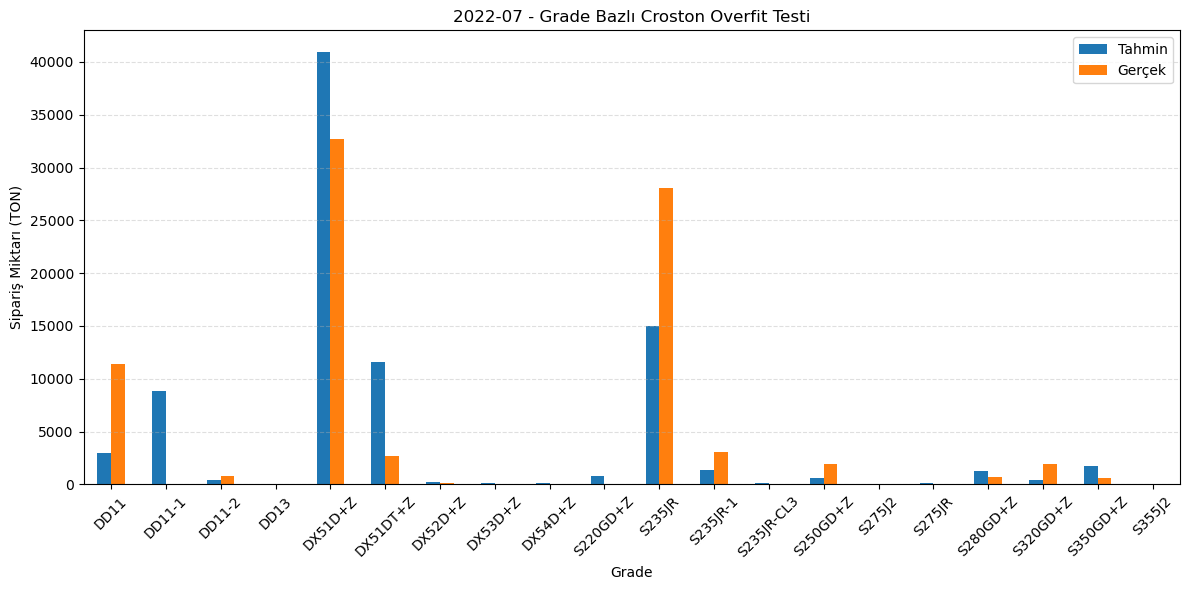

⏳ 2023-03 ayı için CROSTON overfit grafiği hazırlanıyor...


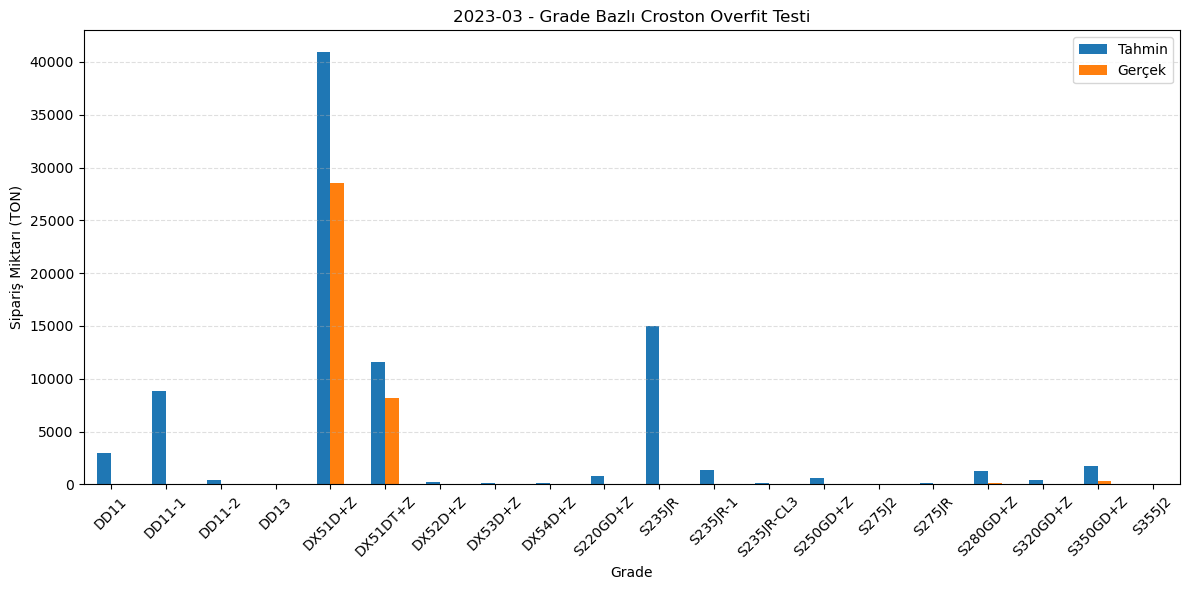

⏳ 2024-01 ayı için CROSTON overfit grafiği hazırlanıyor...


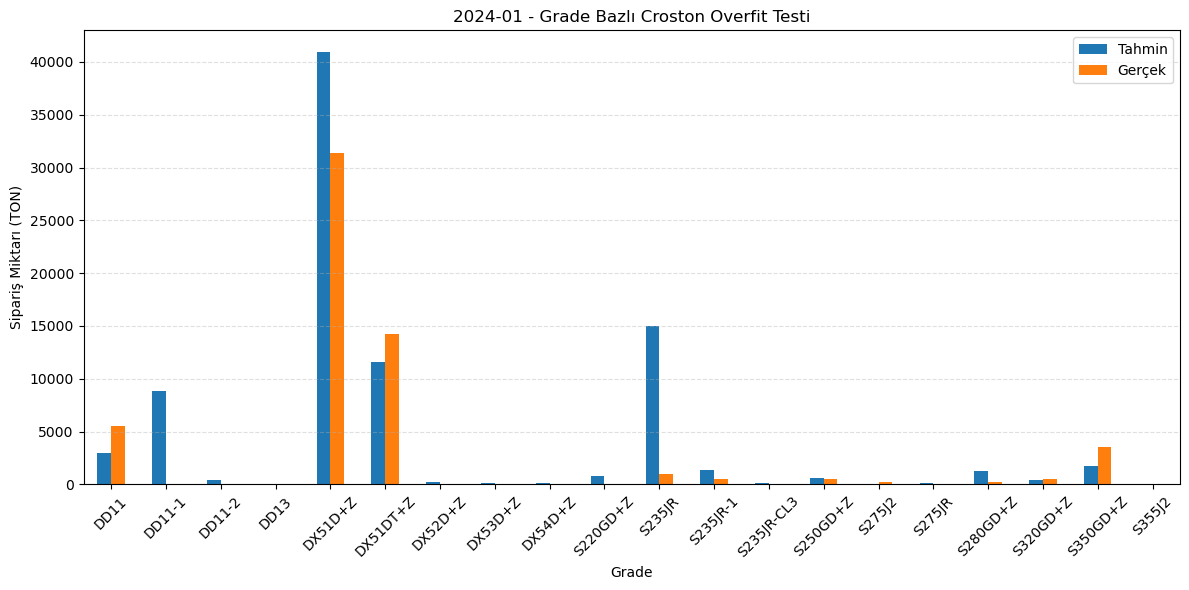

In [31]:
import matplotlib.pyplot as plt

# 🎯 Croston'ın eğitim aralığında kalan ayları seç
target_months = ['2022-07', '2023-03', '2024-01']

for month in target_months:
    print(f"⏳ {month} ayı için CROSTON overfit grafiği hazırlanıyor...")

    forecast_m = train_forecast_df[train_forecast_df['Month'] == pd.to_datetime(month)]
    actual_m = monthly_grade[monthly_grade['Month'] == pd.to_datetime(month)]

    forecast_m = forecast_m[['Grade', 'Forecast_TON']].set_index('Grade')
    actual_m = actual_m[['Grade', 'Sipariş Mik. (TON)']].set_index('Grade')

    common_grades = forecast_m.index.intersection(actual_m.index)

    if len(common_grades) == 0:
        print(f"⚠️ {month} için hem tahmin hem gerçek veri yok.")
        continue

    compare_df = pd.DataFrame({
        'Croston Tahmin': forecast_m.loc[common_grades]['Forecast_TON'],
        'Gerçek': actual_m.loc[common_grades]['Sipariş Mik. (TON)']
    }).sort_index()

    # Grafik
    compare_df.plot(kind='bar', figsize=(12,6), color=['#1f77b4', '#ff7f0e'])
    plt.title(f"{month} - Grade Bazlı Croston Overfit Testi")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.xlabel("Grade")
    plt.xticks(rotation=45)
    plt.legend(["Tahmin", "Gerçek"])
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()


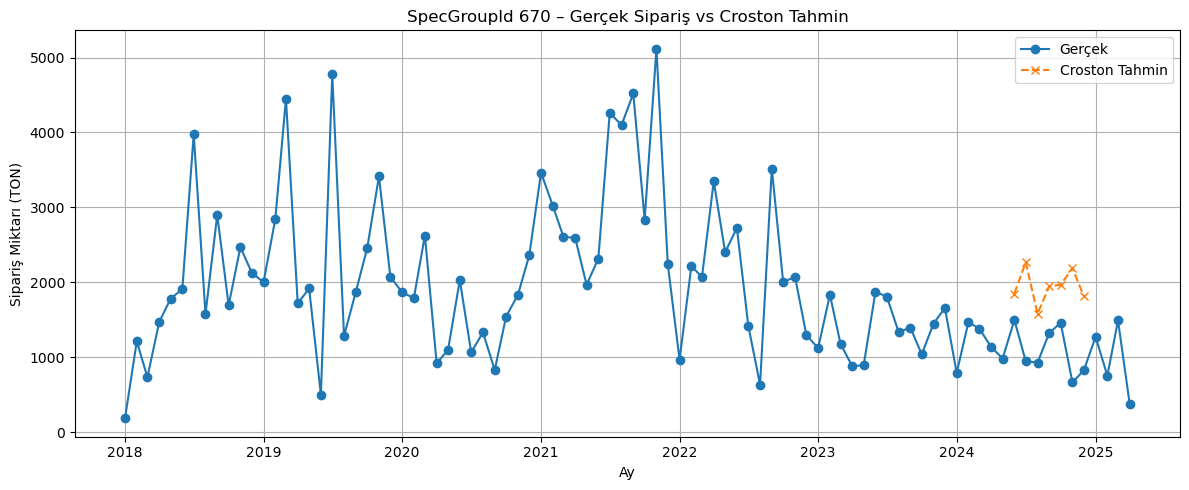

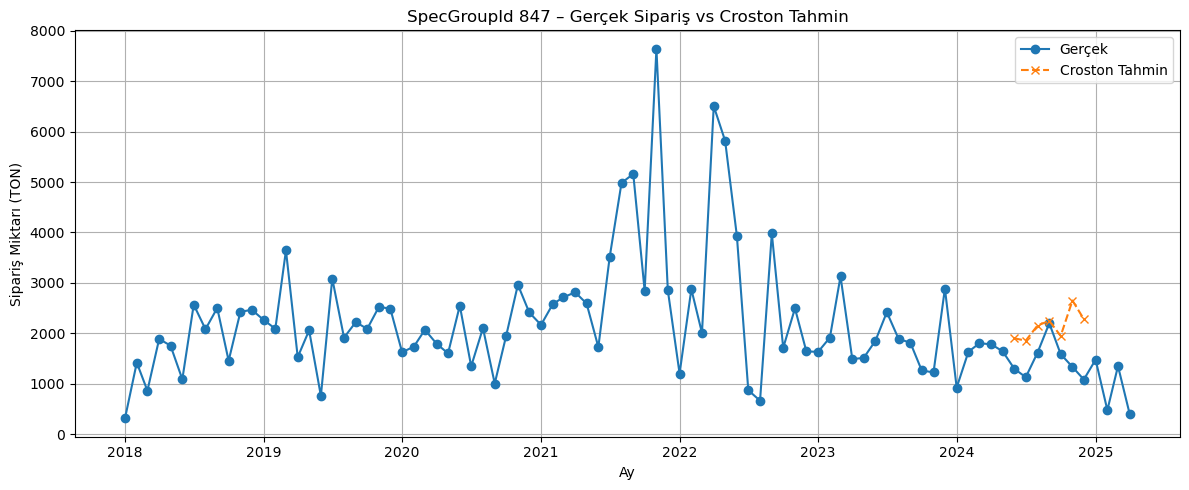

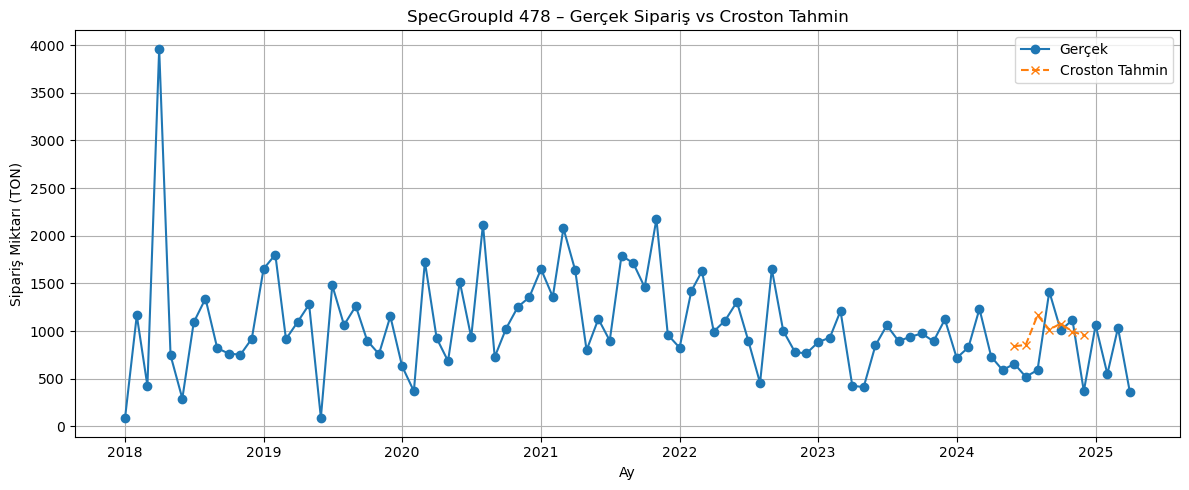

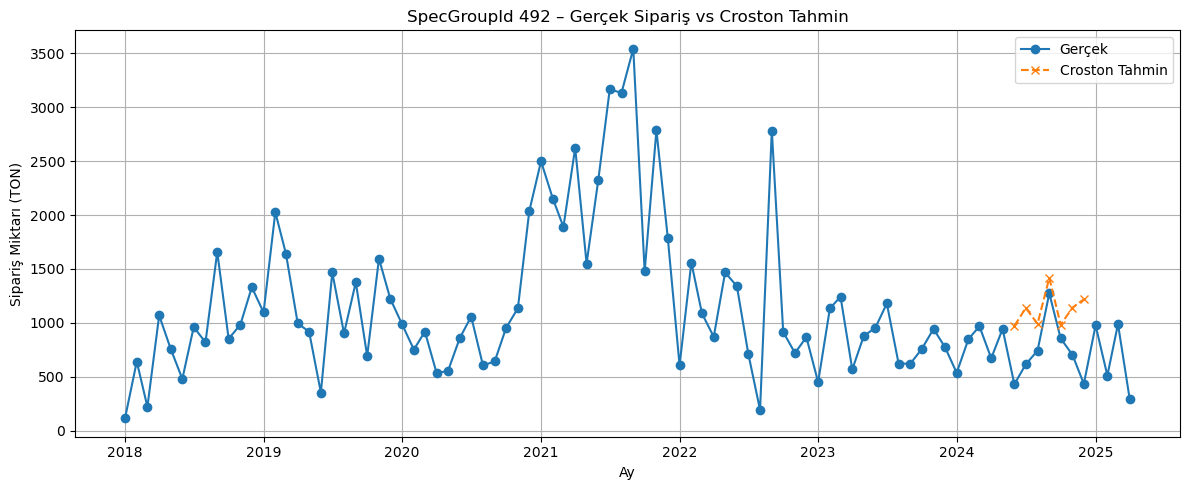

In [33]:
import matplotlib.pyplot as plt

# 🎯 Croston tahminine göre çizmek istediğin SpecGroupId'ler
selected_spec_ids = [ '670', '847','478','492']

for spec_id in selected_spec_ids:
    # 🔹 Gerçek veriler (geçmiş)
    actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
    actual_series = actual_series.groupby('Month').sum().sort_index()
    actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

    # 🔹 Croston tahmin verileri (disaggregated_df kullanılıyor!)
    forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
    forecast_series = forecast_series.groupby('Month').sum().sort_index()
    forecast_series.rename(columns={'Forecast_TON': 'Croston Forecast'}, inplace=True)

    # 🔗 Birleştir
    merged = pd.concat([actual_series, forecast_series], axis=1)

    # 📈 Grafik
    plt.figure(figsize=(12, 5))
    plt.plot(merged.index, merged['Actual'], label='Gerçek', marker='o')
    plt.plot(merged.index, merged['Croston Forecast'], label='Croston Tahmin', linestyle='--', marker='x')
    plt.title(f"SpecGroupId {spec_id} – Gerçek Sipariş vs Croston Tahmin")
    plt.xlabel("Ay")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
